In [ ]:
import pandas as pd
import re

# ------------------- function to filter out LLM thinking process --------------------- #

def is_valid_post(text: str) -> bool:
    if not text or len(text) < 20:
        return False
    # character counting patterns: ->144, =>52, "a"60
    if re.search(r'(=>|->)\s*\d+', text):
        return False
    if re.search(r'"[a-zA-Z0-9]"\s*\d+', text):
        return False
    # space=145, space=158 pattern
    if re.search(r'space=\d+', text):
        return False
    # word counting: "Shows" (5) or "need" (4)
    if re.search(r'"\w+"\s*\(\d+\)', text):
        return False
    # letter enumeration: "T"1, "u"2, "r"3
    if re.search(r'(?:"[a-zA-Z]"\d+,?\s*){3,}', text):
        return False
    # post is too short
    if len(text) < 50:
        return False
    return True

# ------------------------------------------------------------------------------------- #


df = pd.read_csv('post_paper_pairs.csv')

# dropping all NaN entries to make filtering possible
df = df.dropna()


posts = df['social_post'].tolist()
unusable_posts = 0
for post in posts:
  if not is_valid_post(post):
    unusable_posts += 1

print('Number of unusable posts: ',unusable_posts)
print('Number of usable posts:   ',len(posts) - unusable_posts)

# removing rows with unusable posts:
# filtering through boolean mask

valid_mask = df['social_post'].apply(is_valid_post)
df = df[valid_mask]

# checking composition of dataframe after cleaning

print('\nDomain Distribution (Post Filter)\n')
domain_list = df['domain'].unique()
for domain in domain_list:
  print(domain,' : ',len(df[df['domain'] == domain]))

Number of unusable posts:  106
Number of usable posts:    2456

Domain Distribution (Post Filter)

biomedical_health  :  528
nutrition_food_science  :  412
neuroscience_psychology  :  477
biology_genetics  :  529
chemistry_toxicology  :  510


In [ ]:
df.head()

,Unnamed: 0,id,domain,stratum,year,title,abstract,social_post,model
0,0,W3128646645,biomedical_health,high_cited_recent,2021,Global Cancer Statistics 2020: GLOBOCAN Estima...,This article provides an update on the global ...,Just saw that 2020 had ~19.3M new cancer cases...,gpt-oss-120b
1,1,W3118615836,biomedical_health,high_cited_recent,2021,The PRISMA 2020 statement: an updated guidelin...,The Preferred Reporting Items for Systematic r...,Just learned the PRISMA guidelines got a big o...,gpt-oss-120b
2,2,W2889646458,biomedical_health,high_cited_recent,2018,Global cancer statistics 2018: GLOBOCAN estima...,This article provides a status report on the g...,Did you know 2018 saw ~18 million new cancer c...,gpt-oss-120b
3,3,W2891378911,biomedical_health,high_cited_recent,2018,PRISMA Extension for Scoping Reviews (PRISMA-S...,"Scoping reviews, a type of knowledge synthesis...",Just found out the PRISMA-ScR guide for scopin...,gpt-oss-120b
4,4,W3008827533,biomedical_health,high_cited_recent,2020,Clinical Characteristics of Coronavirus Diseas...,"BACKGROUND: Since December 2019, when coronavi...","Turns out the average COVID patient was 47 yo,...",gpt-oss-120b


In [ ]:
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util

# gpu utilization
device = "cuda" if torch.cuda.is_available() else "cpu"

# loading model
model = SentenceTransformer("sentence-transformers/allenai-specter", device=device)

# combining the title and abstract field as source of truth
doc_pairs = list(zip(df['title'], df['abstract']))

print("Encoding query texts...")

query_embeddings = model.encode(
    df['social_post'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_tensor=True
)

print("Encoding document texts...")

doc_embeddings = model.encode(
    doc_pairs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_tensor=True
)

print("Calculating Cosine Similarities...")
cosine_scores = torch.nn.functional.cosine_similarity(query_embeddings, doc_embeddings)

df['specter_similarity'] = cosine_scores.cpu().numpy()
print(df[['specter_similarity']])



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/allenai-specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding query texts...


Batches:   0%|          | 0/39 [00:00<?, ?it/s]

Encoding document texts...


Batches:   0%|          | 0/39 [00:00<?, ?it/s]

Calculating Cosine Similarities...
      specter_similarity
0               0.926800
1               0.960339
2               0.917829
3               0.909266
4               0.798233
...                  ...
2742            0.796679
2743            0.919037
2745            0.872160
2746            0.836940
2748            0.858698

[2456 rows x 1 columns]


The curve below shows that almost 10% of data is below 0.8

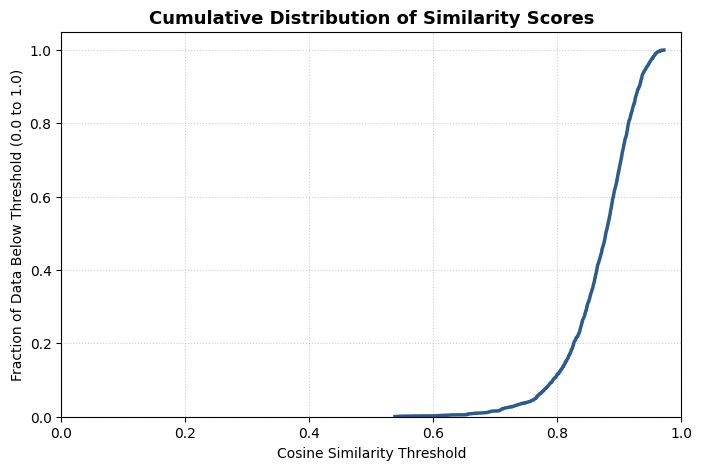

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


scores = df['specter_similarity'].to_numpy()

sorted_scores = np.sort(scores)
y_values = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)

# plotting a cumulative curve to check value distribution
plt.figure(figsize=(8, 5))
plt.plot(sorted_scores, y_values, color='#2b5c8f', linewidth=2.5)

plt.title('Cumulative Distribution of Similarity Scores', fontsize=13, fontweight='bold')
plt.xlabel('Cosine Similarity Threshold')
plt.ylabel('Fraction of Data Below Threshold (0.0 to 1.0)')
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

Checking the length of the trimmed dataframe and domain distribution. Next we will build a stratified training/testing split based on domain.

In [ ]:
# clipping data to see how many will be discarded if the cutoff for similarity is 0.8

selected_df = df[df['specter_similarity'] >= 0.8].copy()
dropped_df = df[df['specter_similarity'] < 0.8].copy()

print('Length of dataset after trimming: ',len(selected_df))
print('Trimmed dataset: ',len(dropped_df))

# domain distribution in trimmed dataset:

print('\n----- Domain Distribution ----\n')
domain_list = selected_df['domain'].unique()
for domain in domain_list:
  print(domain,' : ',len(selected_df[selected_df['domain'] == domain]))

Length of dataset after trimming:  2173
Trimmed dataset:  283

----- Domain Distribution ----

biomedical_health  :  408
nutrition_food_science  :  358
neuroscience_psychology  :  427
biology_genetics  :  511
chemistry_toxicology  :  469


In [ ]:
# we only need the true positive post-paper_id pairs
selected_df = selected_df[['id','domain','social_post']]
selected_df.head()

,id,domain,social_post
0,W3128646645,biomedical_health,Just saw that 2020 had ~19.3M new cancer cases...
1,W3118615836,biomedical_health,Just learned the PRISMA guidelines got a big o...
2,W2889646458,biomedical_health,Did you know 2018 saw ~18 million new cancer c...
3,W2891378911,biomedical_health,Just found out the PRISMA-ScR guide for scopin...
6,W3004280078,biomedical_health,Did you know the virus that started in Wuhan o...


In [ ]:
# generatin and saving training and testing splits

from google.colab import files
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df,test_size=0.20,stratify=df['domain'],random_state=42)

train_df.to_csv('train.csv')
test_df.to_csv('test.csv')

files.download('train.csv')
files.download('test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# sample to recognize normalization patterns
sample_posts = train_df['social_post'].sample(20).tolist()
print(sample_posts)

['Just saw that 2020 had ~19.3M new cancer cases and ~10M deaths worldwide. Breast cancer now tops the list with 2.3M new cases, beating lung cancer. 😳 #cancerstats #health', 'Just heard that giving bamlanivimab + etesevimab to mild COVID patients slashed the virus amount ~3‑fold faster than a placebo. Even bamlanivimab alone cut the load, but the combo was the real MVP 💉🚀 #COVID19 #treatment', 'Turns out the ΔK hack beats the usual “log prob” score for spotting the right number of genetic groups – it nails the top‑level structure in all our test scenarios. 🤯 Marker type and sample size still matter though. #genetics #popgen', 'Mixing cheap salts can lower the melting point by up to 100\u202f°C, letting deep eutectic solvents stay liquid at room temp—thanks to wild hydrogen‑bond networks. 🌡️🔬 #Chemistry #GreenTech', 'Turns out carbon made from MOFs can slash the extra voltage needed for oxygen reduction, oxygen evolution and hydrogen production – all three reactions see lower overpoten

In [ ]:
print('Length of training split: ',len(train_df))
train_df.head()

Length of training split:  1964


,Unnamed: 0,id,domain,stratum,year,title,abstract,social_post,model,specter_similarity
371,371,W3153508314,biomedical_health,high_cited_recent,2021,Safety and Efficacy of Single-Dose Ad26.COV2.S...,BACKGROUND: The Ad26.COV2.S vaccine is a recom...,One shot of J&J's vaccine cuts my risk of gett...,gpt-oss-120b,0.779553
2306,506,W2900653032,chemistry_toxicology,high_cited_recent,2018,Understanding Degradation Mechanisms and Impro...,This review article examines the current state...,Turns out swapping the metal contacts in perov...,gpt-oss-120b,0.907469
2129,329,W1919772617,biology_genetics,high_cited_older,1992,Analysis of molecular variance inferred from m...,We present here a framework for the study of m...,Turns out adding the actual genetic distance b...,gpt-oss-120b,0.934908
1810,10,W3161596995,biology_genetics,high_cited_recent,2021,antiSMASH 6.0: improving cluster detection and...,Many microorganisms produce natural products t...,Just tried antiSMASH 6 – now it can spot 71 di...,gpt-oss-120b,0.894947
2294,494,W2799566423,chemistry_toxicology,high_cited_recent,2018,Expanded Theory of H- and J-Molecular Aggregat...,The electronic excited states of molecular agg...,Turns out the way molecules stack changes thei...,gpt-oss-120b,0.889822


In [ ]:
print('Length of test split: ',len(test_df))
test_df.head()

Length of test split:  492


,Unnamed: 0,id,domain,stratum,year,title,abstract,social_post,model,specter_similarity
1906,106,W2964010366,biology_genetics,high_cited_recent,2018,Recurrent Neural Networks for Multivariate Tim...,Multivariate time series data in practical app...,Turns out missing data can actually help predi...,gpt-oss-120b,0.791987
1340,1340,W3012220842,neuroscience_psychology,high_cited_recent,2020,AI-based chatbots in customer service and thei...,Abstract Communicating with customers through ...,"Turns out, when a chatbot sounds more human an...",gpt-oss-120b,0.888151
311,311,W3006533361,biomedical_health,high_cited_recent,2020,"Isolation, quarantine, social distancing and c...",Public health measures were decisive in contro...,Turns out the old-school stuff—isolating sick ...,gpt-oss-120b,0.871878
1263,1263,W2793346081,neuroscience_psychology,high_cited_recent,2018,Blockchain Meets IoT: An Architecture for Scal...,The Internet of Things (IoT) is stepping out o...,Turns out you can use blockchain to manage who...,gpt-oss-120b,0.903723
2433,633,W2785649357,chemistry_toxicology,high_cited_recent,2018,Volatile chemical products emerging as largest...,A gap in emission inventories of urban volatil...,Turns out half of the fossil‑fuel VOCs puffing...,gpt-oss-120b,0.834340
